# MSDNet Notebook 


In [5]:
# -----------------------------
# Original code cell
# Read the comments above/below for explanation.
# -----------------------------

#import torch → Main PyTorch library (tensor operations, GPU, etc.)
#torch.nn → Used to build neural networks (layers like Conv, Linear)
#torch.optim → Optimizers like Adam, SGD
#torch.nn.functional (F) → Functions like ReLU, softmax
#torchvision → Datasets 
#transforms → Image preprocessing (normalize, resize, etc.)
#matplotlib → For plotting graphs
#numpy → Array operations
import os, random, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # This is used if gpu availabe select it
print("Device:", device)

Device: cuda


# ## 1) Dataset setup (10k train / 1k val / 2k test)

In [ ]:
# -----------------------------
# Original code cell
# Read the comments above/below for explanation.
# -----------------------------

import numpy as np
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms

# -----------------------------
# 1. Transforms
# -----------------------------
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761))
])

# -----------------------------
# 2. Load full datasets
# -----------------------------
train_full = datasets.CIFAR100(
    root='./data', train=True, download=True, transform=transform_train
)

train_full_eval = datasets.CIFAR100(
    root='./data', train=True, download=True, transform=transform_test
)

test_full = datasets.CIFAR100(
    root='./data', train=False, download=True, transform=transform_test
)

# -----------------------------
# 3. Desired subset sizes
# -----------------------------
SUBSET_TRAIN = 10000
SUBSET_VAL   = 2000
SUBSET_TEST  = 2000

# -----------------------------
# 4. Random but reproducible split
# -----------------------------
np.random.seed(42)

train_indices_all = np.random.permutation(len(train_full))   
test_indices_all  = np.random.permutation(len(test_full))    

# Split official training set into train + val
train_idx = train_indices_all[:SUBSET_TRAIN]
val_idx   = train_indices_all[SUBSET_TRAIN:SUBSET_TRAIN + SUBSET_VAL]

# Take test subset from official test set
test_idx  = test_indices_all[:SUBSET_TEST]

# -----------------------------
# 5. Create subsets
# -----------------------------
train_dataset = Subset(train_full, train_idx)         
val_dataset   = Subset(train_full_eval, val_idx)      
test_dataset  = Subset(test_full, test_idx)           

# -----------------------------
# 6. DataLoaders
# -----------------------------
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# -----------------------------
# 7. Check sizes
# -----------------------------
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


100%|██████████| 169M/169M [00:01<00:00, 93.4MB/s] 


Train samples: 10000
Validation samples: 2000
Test samples: 2000


In [7]:
# -----------------------------
# Original code cell
# Read the comments above/below for explanation.
# -----------------------------

# -----------------------------
# 6. SAVE indices
# -----------------------------
import os

os.makedirs("/kaggle/working/splits", exist_ok=True)

np.save("/kaggle/working/splits/train_idx.npy", train_idx)
np.save("/kaggle/working/splits/val_idx.npy", val_idx)
np.save("/kaggle/working/splits/test_idx.npy", test_idx)

print("Split indices saved successfully!")
print("Train:", len(train_idx))
print("Val:", len(val_idx))
print("Test:", len(test_idx))

Split indices saved successfully!
Train: 10000
Val: 2000
Test: 2000


# ## 3) scraatch MSDNet training setup 

In [ ]:
# -----------------------------
# Read the comments above/below for explanation.
# -----------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F


# -----------------------------
# Basic Conv Block
# -----------------------------
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# -----------------------------
# Bottleneck + Conv block
# (to mimic official bottleneck behavior)
# -----------------------------
class BottleneckConv(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, bottleneck_factor=4):
        super().__init__()
        mid_ch = out_ch * bottleneck_factor
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(mid_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# -----------------------------
# 3-scale MSD Layer
# -----------------------------
class MSDLayer3Scale(nn.Module):
    def __init__(self, c1, c2, c3, growth=12, bn_factors=(1,2,4)):
        super().__init__()

        g1 = growth * 1
        g2 = growth * 2
        g3 = growth * 4

        self.s1 = BottleneckConv(c1, g1, stride=1, bottleneck_factor=bn_factors[0])

        self.s2_from_s1 = BottleneckConv(c1, g2, stride=2, bottleneck_factor=bn_factors[1])
        self.s2_from_s2 = BottleneckConv(c2, g2, stride=1, bottleneck_factor=bn_factors[1])

        self.s3_from_s2 = BottleneckConv(c2, g3, stride=2, bottleneck_factor=bn_factors[2])
        self.s3_from_s3 = BottleneckConv(c3, g3, stride=1, bottleneck_factor=bn_factors[2])

        self.g1, self.g2, self.g3 = g1, g2, g3

    def forward(self, x1, x2, x3):
        y1 = self.s1(x1)
        out1 = torch.cat([x1, y1], dim=1)

        y2 = self.s2_from_s1(x1) + self.s2_from_s2(x2)
        out2 = torch.cat([x2, y2], dim=1)

        y3 = self.s3_from_s2(x2) + self.s3_from_s3(x3)
        out3 = torch.cat([x3, y3], dim=1)

        return out1, out2, out3


# -----------------------------
# 2-scale MSD Layer
# -----------------------------
class MSDLayer2Scale(nn.Module):
    def __init__(self, c2, c3, growth=12, bn_factors=(2,4)):
        super().__init__()

        g2 = growth * 2
        g3 = growth * 4

        self.s2 = BottleneckConv(c2, g2, stride=1, bottleneck_factor=bn_factors[0])

        self.s3_from_s2 = BottleneckConv(c2, g3, stride=2, bottleneck_factor=bn_factors[1])
        self.s3_from_s3 = BottleneckConv(c3, g3, stride=1, bottleneck_factor=bn_factors[1])

        self.g2, self.g3 = g2, g3

    def forward(self, x2, x3):
        y2 = self.s2(x2)
        out2 = torch.cat([x2, y2], dim=1)

        y3 = self.s3_from_s2(x2) + self.s3_from_s3(x3)
        out3 = torch.cat([x3, y3], dim=1)

        return out2, out3


# -----------------------------
# 1-scale MSD Layer
# -----------------------------
class MSDLayer1Scale(nn.Module):
    def __init__(self, c3, growth=12, bn_factor=4):
        super().__init__()
        g3 = growth * 4
        self.s3 = BottleneckConv(c3, g3, stride=1, bottleneck_factor=bn_factor)
        self.g3 = g3

    def forward(self, x3):
        y3 = self.s3(x3)
        out3 = torch.cat([x3, y3], dim=1)
        return out3


# -----------------------------
# Transition Layer
# -----------------------------
class TransitionLayer(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.trans = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.trans(x)


# -----------------------------
# Early Exit Classifier
# -----------------------------
class EarlyExitClassifier(nn.Module):
    def __init__(self, in_ch, num_classes=100):
        super().__init__()
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(in_ch, num_classes)
        )

    def forward(self, x):
        return self.head(x)


# -----------------------------
# FINAL SCRATCH MSDNet
# -----------------------------
class ScratchMSDNet(nn.Module):
    def __init__(self, num_classes=100, growth=12):
        super().__init__()

        # Initial stems
        self.stem1 = ConvBNReLU(3, 32)                  # scale 1
        self.stem2 = ConvBNReLU(32, 64, stride=2)      # scale 2
        self.stem3 = ConvBNReLU(64, 128, stride=2)     # scale 3

        # -------------------------
        # Block 1 (4 layers, 3 scales)
        # -------------------------
        self.b1_l1 = MSDLayer3Scale(32, 64, 128, growth)
        self.b1_l2 = MSDLayer3Scale(44, 88, 176, growth)
        self.b1_l3 = MSDLayer3Scale(56, 112, 224, growth)
        self.b1_l4 = MSDLayer3Scale(68, 136, 272, growth)

        # Exit 1
        self.exit1 = EarlyExitClassifier(320, num_classes)

        # Transition to Block 2 (drop scale 1)
        self.trans_b2_s2 = TransitionLayer(160, 96)
        self.trans_b2_s3 = TransitionLayer(320, 192)

        # -------------------------
        # Block 2 (2 layers, 2 scales)
        # -------------------------
        self.b2_l1 = MSDLayer2Scale(96, 192, growth)
        self.b2_l2 = MSDLayer2Scale(120, 240, growth)

        # Exit 2
        self.exit2 = EarlyExitClassifier(288, num_classes)

        # Transition to Block 3 (drop scale 2)
        self.trans_b3_s3 = TransitionLayer(288, 224)

        # -------------------------
        # Block 3 (2 layers)
        # First layer still 2-scale
        # Then drop to 1-scale
        # -------------------------
        self.b3_l1 = MSDLayer2Scale(144, 224, growth)
        self.trans_b3_final = TransitionLayer(272, 256)
        self.b3_l2 = MSDLayer1Scale(256, growth)

        # Exit 3
        self.exit3 = EarlyExitClassifier(304, num_classes)

    def forward(self, x):
        # Initial stems
        x1 = self.stem1(x)   # [B, 32, 32, 32]
        x2 = self.stem2(x1)  # [B, 64, 16, 16]
        x3 = self.stem3(x2)  # [B, 128, 8, 8]

        # -------------------------
        # Block 1
        # -------------------------
        x1, x2, x3 = self.b1_l1(x1, x2, x3)
        x1, x2, x3 = self.b1_l2(x1, x2, x3)
        x1, x2, x3 = self.b1_l3(x1, x2, x3)
        x1, x2, x3 = self.b1_l4(x1, x2, x3)

        out1 = self.exit1(x3)

        # -------------------------
        # Transition to Block 2
        # -------------------------
        x2 = self.trans_b2_s2(x2)
        x3 = self.trans_b2_s3(x3)

        # -------------------------
        # Block 2
        # -------------------------
        x2, x3 = self.b2_l1(x2, x3)
        x2, x3 = self.b2_l2(x2, x3)

        out2 = self.exit2(x3)

        # -------------------------
        # Transition to Block 3
        # -------------------------
        x2 = x2
        x3 = self.trans_b3_s3(x3)

        # -------------------------
        # Block 3
        # -------------------------
        x2, x3 = self.b3_l1(x2, x3)
        x3 = self.trans_b3_final(x3)
        x3 = self.b3_l2(x3)

        out3 = self.exit3(x3)

        return [out1, out2, out3]


# -----------------------------
# Build model
# -----------------------------
model = ScratchMSDNet(num_classes=100, growth=12).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {total_params/1e6:.2f} M")

ScratchMSDNet(
  (stem1): ConvBNReLU(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (stem2): ConvBNReLU(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (stem3): ConvBNReLU(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (b1_l1): MSDLayer3Scale(
    (s1): BottleneckConv(
      (block): Sequential(
        (0): Conv2d(32, 12, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(

In [ ]:
# -----------------------------
# Optimization and scheduler
# -----------------------------

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4,
    nesterov=True
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[20, 30],
    gamma=0.1
)

EPOCHS = 40

In [ ]:
# -----------------------------
# Training and evaluation functions
# -----------------------------

def train_one_epoch(loader):
    model.train()
    running_loss = 0.0
    total = 0
    correct = None

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        if correct is None:
            correct = [0] * len(outputs)

        # Fairer MSD-style supervision: all exits are trained equally
        loss = sum(criterion(out, labels) for out in outputs)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total += labels.size(0)

        for i, out in enumerate(outputs):
            preds = out.argmax(dim=1)
            correct[i] += (preds == labels).sum().item()

    avg_loss = running_loss / len(loader)
    accs = [c / total for c in correct]
    return avg_loss, accs

@torch.no_grad()
def evaluate(loader):
    model.eval()
    running_loss = 0.0
    total = 0
    correct = None

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        if correct is None:
            correct = [0] * len(outputs)

        loss = sum(criterion(out, labels) for out in outputs)

        running_loss += loss.item()
        total += labels.size(0)

        for i, out in enumerate(outputs):
            preds = out.argmax(dim=1)
            correct[i] += (preds == labels).sum().item()

    avg_loss = running_loss / len(loader)
    accs = [c / total for c in correct]
    return avg_loss, accs

# ## 4) Training loop

In [ ]:
# -----------------------------
# Training loop
# -----------------------------

train_losses, val_losses = [], []
train_exit_accs, val_exit_accs = [], []

best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_accs = train_one_epoch(train_loader)
    val_loss, val_accs = evaluate(val_loader)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_exit_accs.append(train_accs)
    val_exit_accs.append(val_accs)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"LR {optimizer.param_groups[0]['lr']:.5f} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {[round(a*100,2) for a in train_accs]} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {[round(a*100,2) for a in val_accs]}"
    )

    if val_accs[-1] > best_val_acc:
        best_val_acc = val_accs[-1]
        torch.save(model.state_dict(), "best_scratch_msdnet.pth")
        print("Best model saved!")

Epoch 1/40 | LR 0.10000 | Train Loss 12.7238 | Train Acc [5.78, 6.02, 5.89] | Val Loss 13.3822 | Val Acc [7.5, 6.2, 5.6]
Best model saved!
Epoch 2/40 | LR 0.10000 | Train Loss 11.6166 | Train Acc [9.46, 9.76, 9.39] | Val Loss 11.9756 | Val Acc [10.4, 10.05, 10.2]
Best model saved!
Epoch 3/40 | LR 0.10000 | Train Loss 11.0033 | Train Acc [12.33, 12.81, 12.07] | Val Loss 11.0487 | Val Acc [13.95, 15.25, 15.0]
Best model saved!
Epoch 4/40 | LR 0.10000 | Train Loss 10.3209 | Train Acc [15.5, 16.8, 15.95] | Val Loss 11.1942 | Val Acc [13.4, 13.8, 12.55]
Epoch 5/40 | LR 0.10000 | Train Loss 9.6979 | Train Acc [18.86, 21.34, 20.11] | Val Loss 10.5653 | Val Acc [16.5, 21.35, 19.7]
Best model saved!
Epoch 6/40 | LR 0.10000 | Train Loss 9.0946 | Train Acc [21.5, 24.97, 24.14] | Val Loss 10.0705 | Val Acc [22.3, 21.9, 22.15]
Best model saved!
Epoch 7/40 | LR 0.10000 | Train Loss 8.5923 | Train Acc [25.16, 27.69, 27.07] | Val Loss 9.4589 | Val Acc [24.25, 25.75, 24.15]
Best model saved!
Epoch 8/40

# ## 5) Plot curves

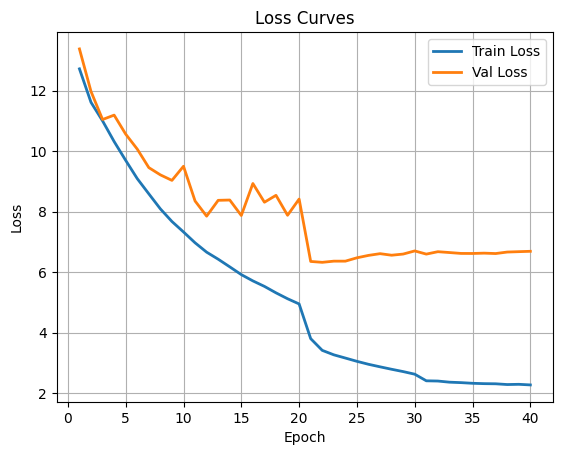

In [ ]:
# -----------------------------
# Plotting code
# -----------------------------

train_exit_accs_np = np.array(train_exit_accs)
val_exit_accs_np = np.array(val_exit_accs)
epochs_range = range(1, len(train_losses) + 1)

plt.plot(epochs_range, train_losses, label="Train Loss", linewidth=2)
plt.plot(epochs_range, val_losses, label="Val Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)

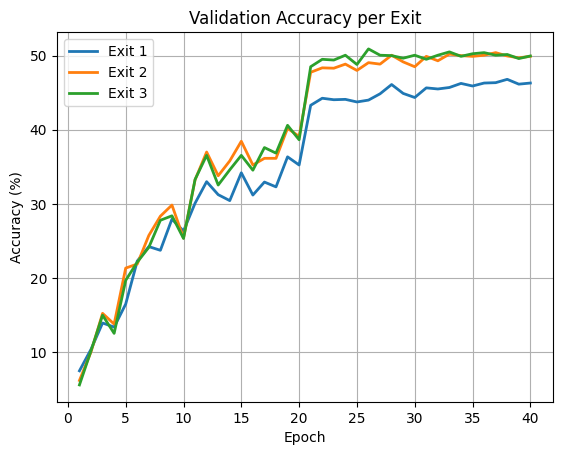

In [ ]:
# -----------------------------
# Validation accuracy per exit
# -----------------------------

for i in range(val_exit_accs_np.shape[1]):
    plt.plot(epochs_range, val_exit_accs_np[:, i] * 100, label=f'Exit {i+1}', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy per Exit")
plt.legend()
plt.grid(True)

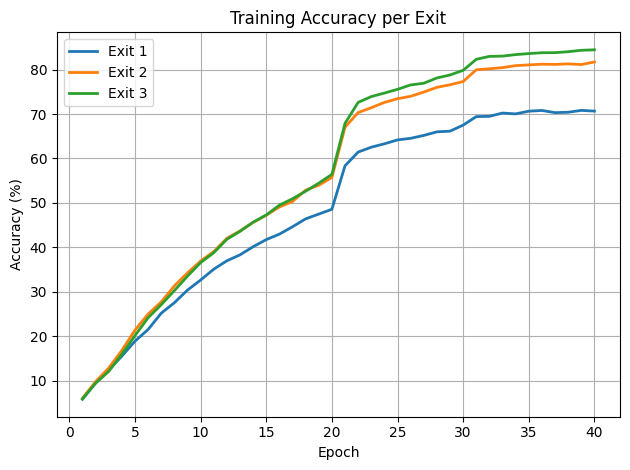

In [ ]:
# -----------------------------
# Training accuracy per exit
# -----------------------------

for i in range(train_exit_accs_np.shape[1]):
    plt.plot(epochs_range, train_exit_accs_np[:, i] * 100, label=f'Exit {i+1}', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy per Exit")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ## 6) Test evaluation

In [ ]:
# -----------------------------
# Test evaluation
# -----------------------------

model.load_state_dict(torch.load("best_scratch_msdnet.pth", map_location=device))

test_loss, test_accs = evaluate(test_loader)

print("===== TEST RESULTS =====")
print(f"Test Loss: {test_loss:.4f}")
for i, acc in enumerate(test_accs):
    print(f"Exit {i+1} Accuracy: {acc*100:.2f}%")

===== TEST RESULTS =====
Test Loss: 6.6448
Exit 1 Accuracy: 42.65%
Exit 2 Accuracy: 47.35%
Exit 3 Accuracy: 49.10%


# ## 7) FLOPs / Params per exit

In [ ]:
# -----------------------------
# FLOPs and parameter count
# -----------------------------

!pip install -q thop
from thop import profile
import torch
import torch.nn as nn

class ScratchEarlyExitWrapper(nn.Module):
    def __init__(self, model, exit_idx):
        super().__init__()
        self.model = model
        self.exit_idx = exit_idx

    def forward(self, x):
        # Initial stems
        x1 = self.model.stem1(x)
        x2 = self.model.stem2(x1)
        x3 = self.model.stem3(x2)

        # Block 1
        x1, x2, x3 = self.model.b1_l1(x1, x2, x3)
        x1, x2, x3 = self.model.b1_l2(x1, x2, x3)
        x1, x2, x3 = self.model.b1_l3(x1, x2, x3)
        x1, x2, x3 = self.model.b1_l4(x1, x2, x3)

        if self.exit_idx == 0:
            return self.model.exit1(x3)

        # Transition to Block 2
        x2 = self.model.trans_b2_s2(x2)
        x3 = self.model.trans_b2_s3(x3)

        # Block 2
        x2, x3 = self.model.b2_l1(x2, x3)
        x2, x3 = self.model.b2_l2(x2, x3)

        if self.exit_idx == 1:
            return self.model.exit2(x3)

        # Transition to Block 3
        x3 = self.model.trans_b3_s3(x3)

        # Block 3
        x2, x3 = self.model.b3_l1(x2, x3)
        x3 = self.model.trans_b3_final(x3)
        x3 = self.model.b3_l2(x3)

        return self.model.exit3(x3)


dummy_input = torch.randn(1, 3, 32, 32).to(device)

flops_list = []
params_list = []

for i in range(3):
    wrapped_model = ScratchEarlyExitWrapper(model, i).to(device)
    flops, params = profile(wrapped_model, inputs=(dummy_input,), verbose=False)
    flops_list.append(flops)
    params_list.append(params)

for i in range(3):
    print(f"Exit {i+1}: FLOPs = {flops_list[i]/1e6:.2f} MFLOPs | Params = {params_list[i]/1e6:.2f} M")

Exit 1: FLOPs = 128.96 MFLOPs | Params = 1.14 M
Exit 2: FLOPs = 182.78 MFLOPs | Params = 1.71 M
Exit 3: FLOPs = 225.22 MFLOPs | Params = 2.23 M


In [ ]:
# -----------------------------
# Output shapes at each exit
# -----------------------------

images, labels = next(iter(train_loader))
images = images.to(device)

outputs = model(images)

print("Output type:", type(outputs))
print("Number of exits:", len(outputs))
for i, out in enumerate(outputs):
    print(f"Exit {i+1} shape:", out.shape)

Output type: <class 'list'>
Number of exits: 3
Exit 1 shape: torch.Size([64, 100])
Exit 2 shape: torch.Size([64, 100])
Exit 3 shape: torch.Size([64, 100])


# ## 8) Anytime prediction curve

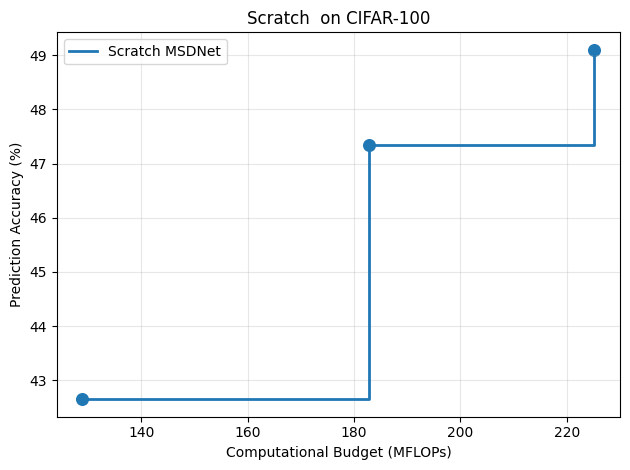

In [ ]:
# -----------------------------
# Anytime prediction plot   
# -----------------------------

import matplotlib.pyplot as plt

# Scratch
scratch_budgets = [f / 1e6 for f in flops_list]
scratch_accs = [float(a) * 100 for a in test_accs]
scratch_pairs = sorted(zip(scratch_budgets, scratch_accs))
scratch_budgets, scratch_accs = zip(*scratch_pairs)

# Scratch
plt.step(scratch_budgets, scratch_accs, where='post', linewidth=2, label='Scratch MSDNet')
plt.scatter(scratch_budgets, scratch_accs, s=70)


plt.xlabel("Computational Budget (MFLOPs)")
plt.ylabel("Prediction Accuracy (%)")
plt.title("Scratch  on CIFAR-100")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ## 9) Budget Based Classification curve

In [ ]:
# -----------------------------
# Budgeted evaluation function
# -----------------------------

import torch.nn.functional as F

#flops_list = [FLOPs up to exit 1,FLOPs up to exit 2,FLOPs up to exit 3]

@torch.no_grad()
def budgeted_evaluate(model, loader, thresholds, flops_list, device=device):
    model.eval()

    correct = 0
    total = 0
    total_flops = 0

    exit_counts = [0, 0, 0]

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)   # list of outputs from all exits
        batch_size = labels.size(0)

        for i in range(batch_size):
            sample_exited = False

            for exit_idx in range(3):
                logits = outputs[exit_idx][i].unsqueeze(0)
                probs = torch.softmax(logits, dim=1)
                conf, pred = torch.max(probs, dim=1)

                if conf.item() >= thresholds[exit_idx] or exit_idx == 2:
                    correct += (pred == labels[i]).sum().item()
                    total += 1
                    total_flops += flops_list[exit_idx]
                    exit_counts[exit_idx] += 1
                    sample_exited = True
                    break

            if not sample_exited:
                # fallback (should never happen because exit 3 always exits)
                logits = outputs[-1][i].unsqueeze(0)
                pred = logits.argmax(dim=1)
                correct += (pred == labels[i]).sum().item()
                total += 1
                total_flops += flops_list[-1]
                exit_counts[-1] += 1

    avg_flops = total_flops / total
    acc = 100.0 * correct / total

    return avg_flops, acc, exit_counts

In [ ]:
# -----------------------------
# Budgeted evaluation with different thresholds
# -----------------------------

threshold_settings = [
    [0.999, 0.999, 0.0],
    [0.995, 0.995, 0.0],
    [0.990, 0.990, 0.0],
    [0.970, 0.970, 0.0],
    [0.950, 0.950, 0.0],
    [0.900, 0.900, 0.0],
    [0.850, 0.850, 0.0],
    [0.800, 0.800, 0.0],
    [0.700, 0.700, 0.0],
    [0.600, 0.600, 0.0],
    [0.500, 0.500, 0.0],
]
budgets_batch, accs_batch = [], []

for th in threshold_settings:
    avg_flops, acc, exit_counts = budgeted_evaluate(model, test_loader, th, flops_list)

    budgets_batch.append(avg_flops)
    accs_batch.append(acc)

    total_samples = sum(exit_counts)
    e1 = 100 * exit_counts[0] / total_samples
    e2 = 100 * exit_counts[1] / total_samples
    e3 = 100 * exit_counts[2] / total_samples

    print(f"Thresholds {th}")
    print(f"  Avg Budget: {avg_flops:.2f} MFLOPs | Accuracy: {acc:.2f}%")
    print(f"  Exit 1: {exit_counts[0]} ({e1:.2f}%)")
    print(f"  Exit 2: {exit_counts[1]} ({e2:.2f}%)")
    print(f"  Exit 3: {exit_counts[2]} ({e3:.2f}%)")
    print("-"*50)

Thresholds [0.999, 0.999, 0.0]
  Avg Budget: 223510112.41 MFLOPs | Accuracy: 49.10%
  Exit 1: 17 (0.85%)
  Exit 2: 42 (2.10%)
  Exit 3: 1941 (97.05%)
--------------------------------------------------
Thresholds [0.995, 0.995, 0.0]
  Avg Budget: 221007847.44 MFLOPs | Accuracy: 49.10%
  Exit 1: 54 (2.70%)
  Exit 2: 76 (3.80%)
  Exit 3: 1870 (93.50%)
--------------------------------------------------
Thresholds [0.99, 0.99, 0.0]
  Avg Budget: 218968278.38 MFLOPs | Accuracy: 49.10%
  Exit 1: 88 (4.40%)
  Exit 2: 95 (4.75%)
  Exit 3: 1817 (90.85%)
--------------------------------------------------
Thresholds [0.97, 0.97, 0.0]
  Avg Budget: 214811045.28 MFLOPs | Accuracy: 49.10%
  Exit 1: 166 (8.30%)
  Exit 2: 114 (5.70%)
  Exit 3: 1720 (86.00%)
--------------------------------------------------
Thresholds [0.95, 0.95, 0.0]
  Avg Budget: 211974508.49 MFLOPs | Accuracy: 49.15%
  Exit 1: 217 (10.85%)
  Exit 2: 132 (6.60%)
  Exit 3: 1651 (82.55%)
-----------------------------------------------

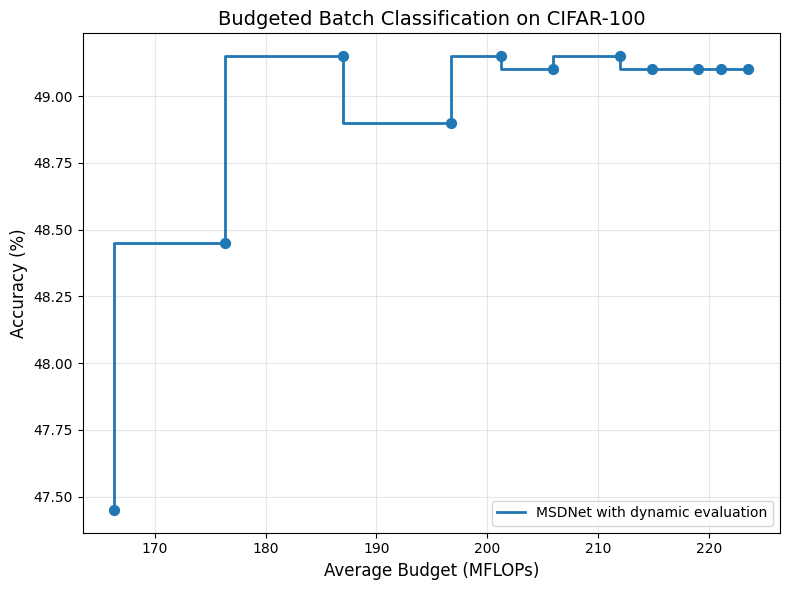

In [ ]:
# -----------------------------
#Budgeted evaluation with different thresholds
# -----------------------------

budgets_batch_mflops = [b / 1e6 for b in budgets_batch]

plt.figure(figsize=(8, 6))
plt.step(budgets_batch_mflops, accs_batch, where='post', linewidth=2, label="MSDNet with dynamic evaluation")
plt.scatter(budgets_batch_mflops, accs_batch, s=50)

plt.title("Budgeted Batch Classification on CIFAR-100", fontsize=14)
plt.xlabel("Average Budget (MFLOPs)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()